# EDA

This notebook performs a quick exploratory data analysis (EDA) on the dataset stored in `../data/` (train and val). It shows class distribution, samples of images, and image size distribution to help plan preprocessing and modeling.

In [26]:
import sys
from pathlib import Path
project_root = Path.cwd().parent  
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from PIL import Image
%matplotlib inline
from src.dataloader import TomatoDataset
from src.preprocess import remove_background, train_transform
from src.visualization import show_samples, plot_pixel_distribution
from config import TRAIN_DIR, VAL_DIR

## Class distribution (counts per folder)

In [19]:
def class_counts(folder: Path) -> pd.DataFrame:
    classes = []
    if not folder.exists():
        return pd.DataFrame({'class': [], 'count': []})
    for sub in sorted(folder.iterdir()):
        if sub.is_dir():
            n = len(list(sub.glob('*')))
            classes.append((sub.name, n))
    df = pd.DataFrame(classes, columns=['class', 'count']).sort_values('count', ascending=False).reset_index(drop=True)
    return df

train_counts = class_counts(Path(TRAIN_DIR))
val_counts = class_counts(Path(VAL_DIR))

merged_counts = train_counts.merge(val_counts, on='class', how='outer', suffixes=('_train', '_val')).fillna(0)
merged_counts = merged_counts.astype({'count_train': int, 'count_val': int})
merged_counts = merged_counts.sort_values('count_train', ascending=False).reset_index(drop=True)
display(merged_counts)

,class,count_train,count_val
0,Tomato___Bacterial_spot,1000,100
1,Tomato___Early_blight,1000,100
2,Tomato___Late_blight,1000,100
3,Tomato___Leaf_Mold,1000,100
4,Tomato___Septoria_leaf_spot,1000,100
5,Tomato___Spider_mites Two-spotted_spider_mite,1000,100
6,Tomato___Target_Spot,1000,100
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,1000,100
8,Tomato___Tomato_mosaic_virus,1000,100
9,Tomato___healthy,1000,100


## Show sample images (one per class)

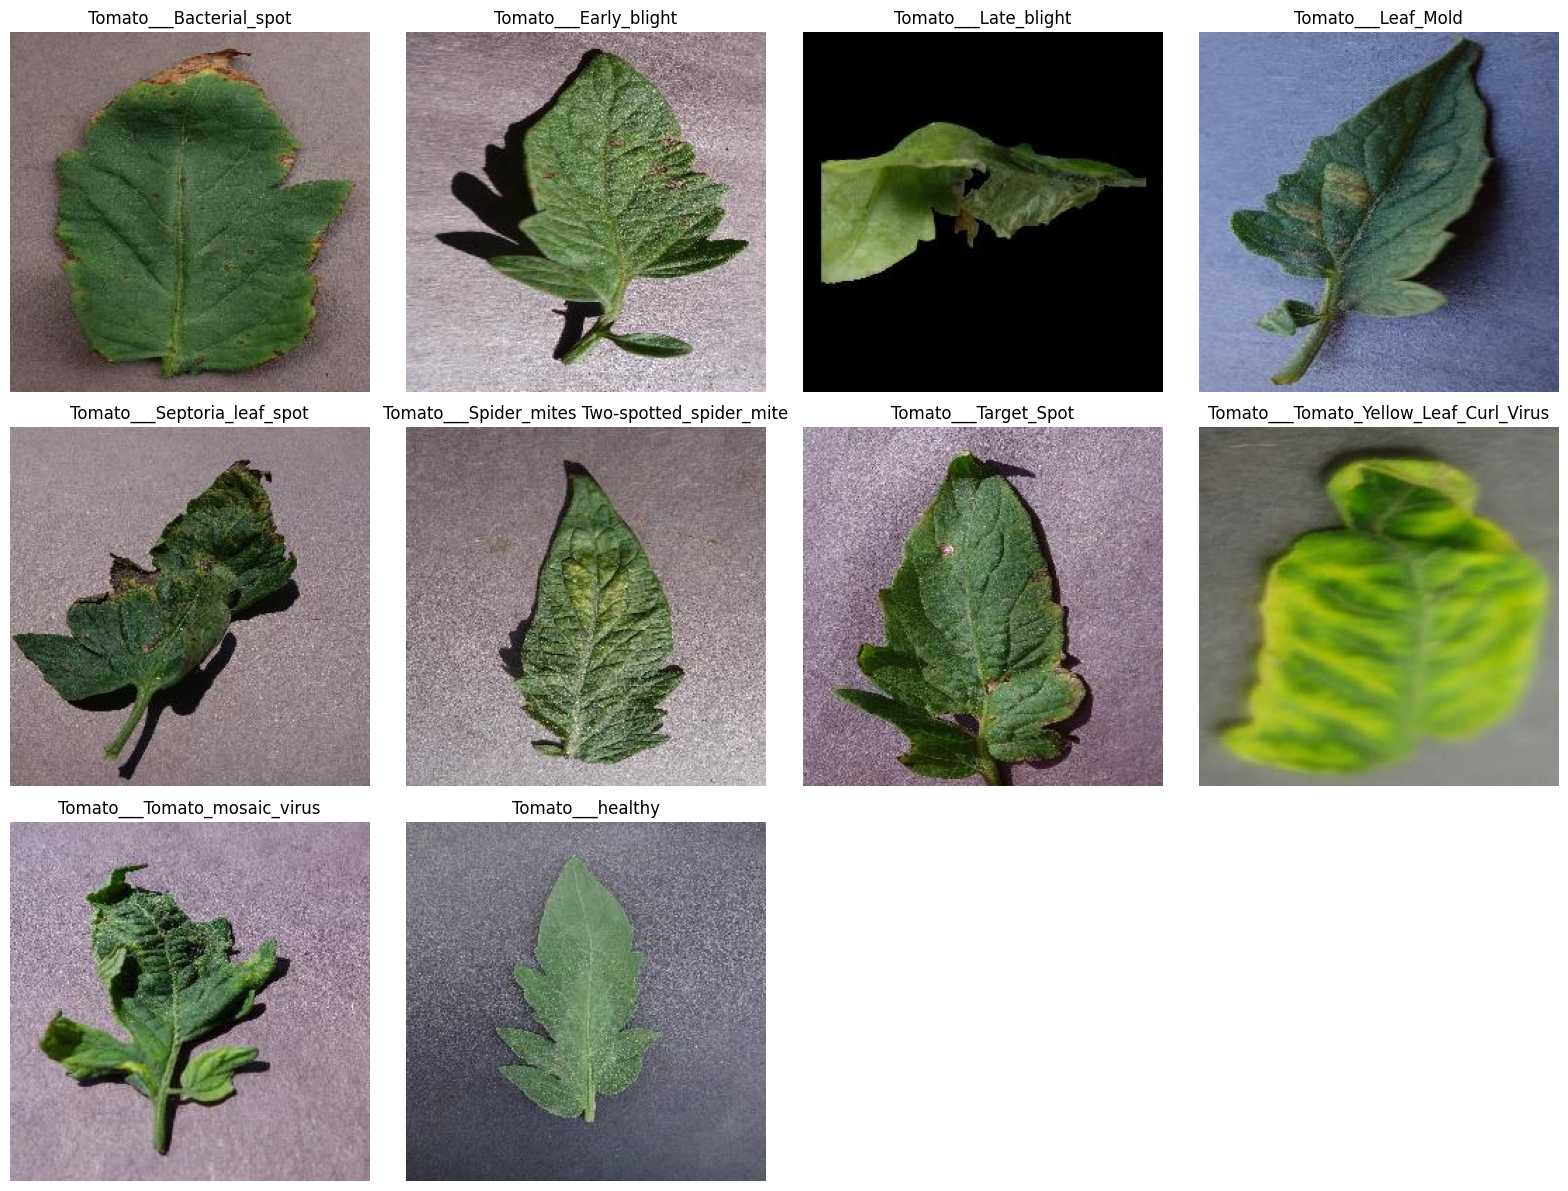

In [21]:
show_samples(Path(TRAIN_DIR), ncols=4, max_classes=12)

## File sample table and next steps

In [23]:
# Show a small sample table for the train set
rows = []
for sub in sorted(Path(TRAIN_DIR).iterdir()):
    if sub.is_dir():
        imgs = list(sub.glob('*'))[:5]
        for p in imgs:
            rows.append({'class': sub.name, 'file': str(p)})
df = pd.DataFrame(rows)
df.head(10)

,class,file
0,Tomato___Bacterial_spot,/Users/ndeyeawasalane/Downloads/tomato-disease...
1,Tomato___Bacterial_spot,/Users/ndeyeawasalane/Downloads/tomato-disease...
2,Tomato___Bacterial_spot,/Users/ndeyeawasalane/Downloads/tomato-disease...
3,Tomato___Bacterial_spot,/Users/ndeyeawasalane/Downloads/tomato-disease...
4,Tomato___Bacterial_spot,/Users/ndeyeawasalane/Downloads/tomato-disease...
5,Tomato___Early_blight,/Users/ndeyeawasalane/Downloads/tomato-disease...
6,Tomato___Early_blight,/Users/ndeyeawasalane/Downloads/tomato-disease...
7,Tomato___Early_blight,/Users/ndeyeawasalane/Downloads/tomato-disease...
8,Tomato___Early_blight,/Users/ndeyeawasalane/Downloads/tomato-disease...
9,Tomato___Early_blight,/Users/ndeyeawasalane/Downloads/tomato-disease...


## Pixel value distribution per class

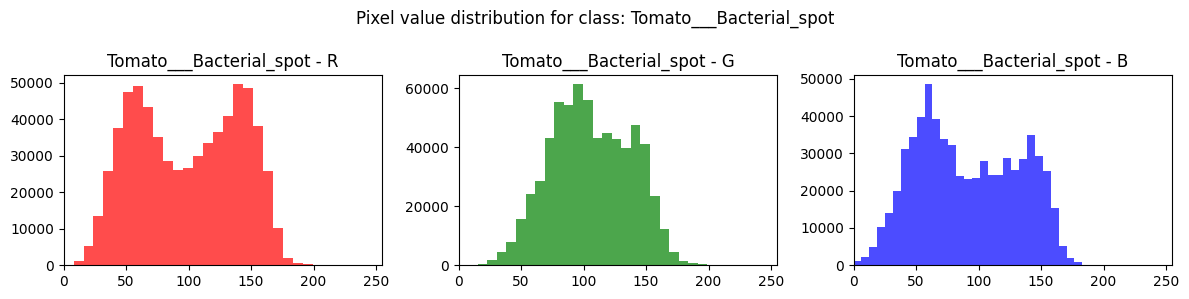

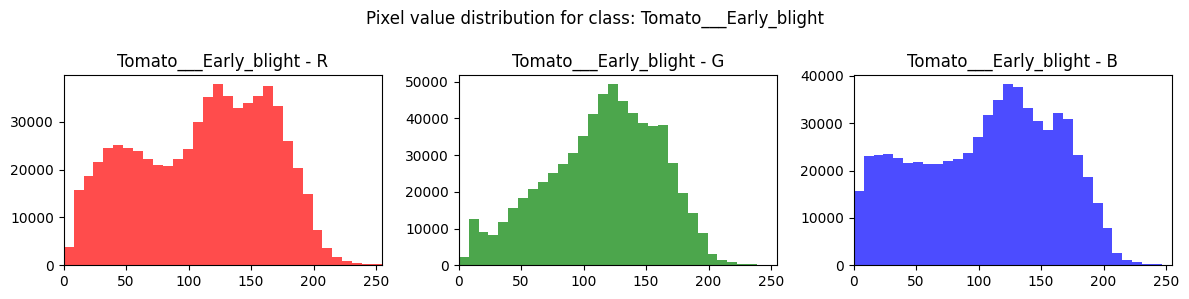

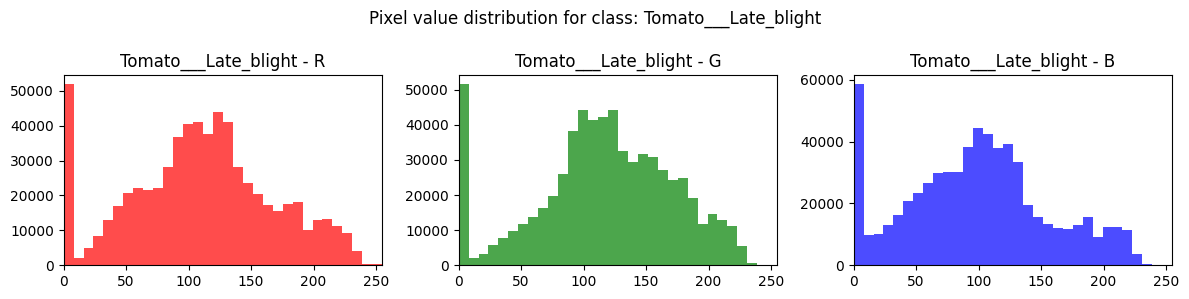

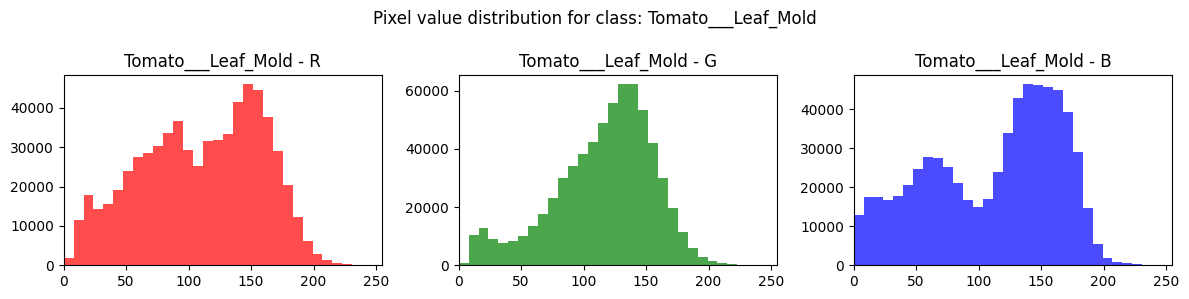

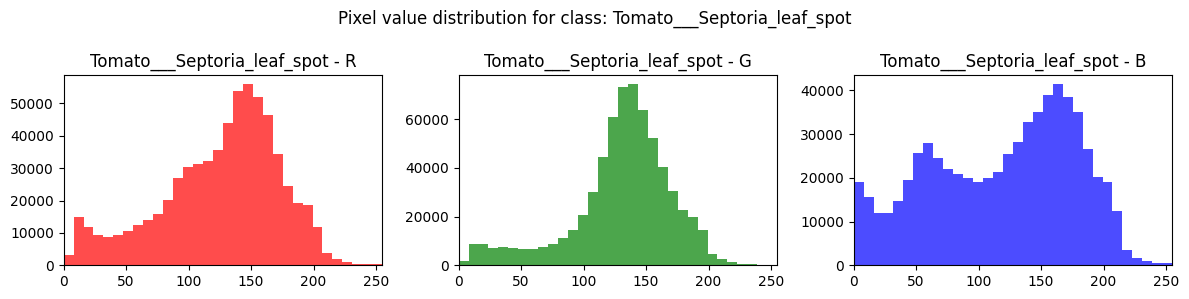

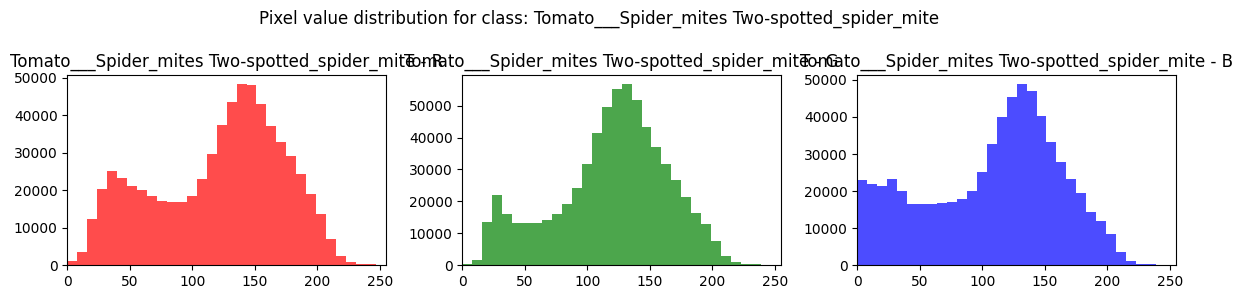

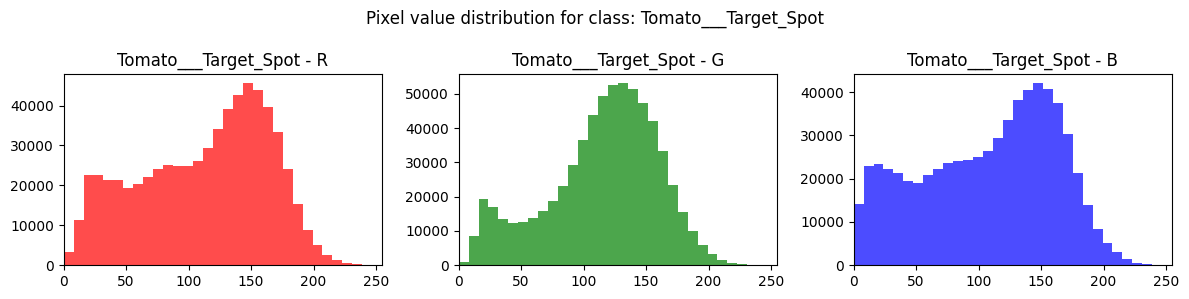

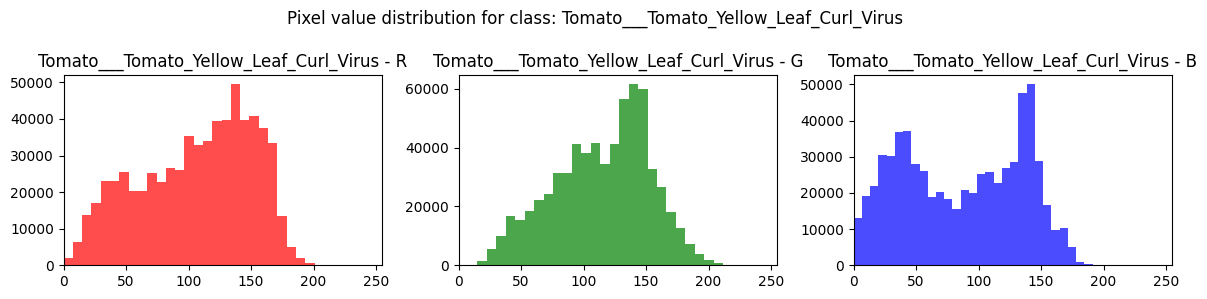

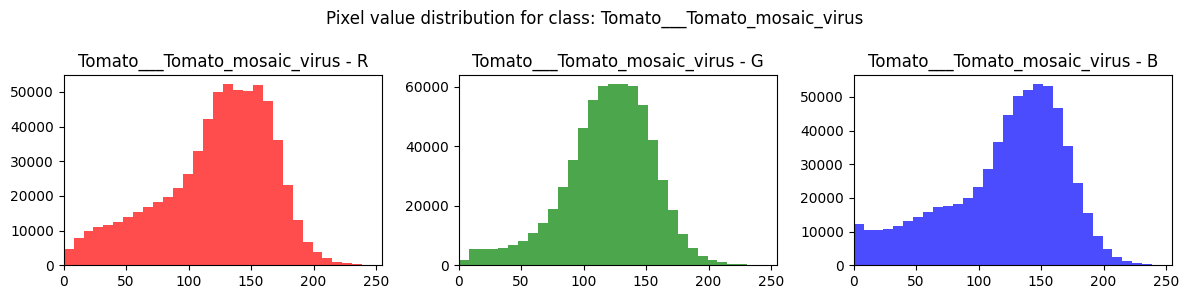

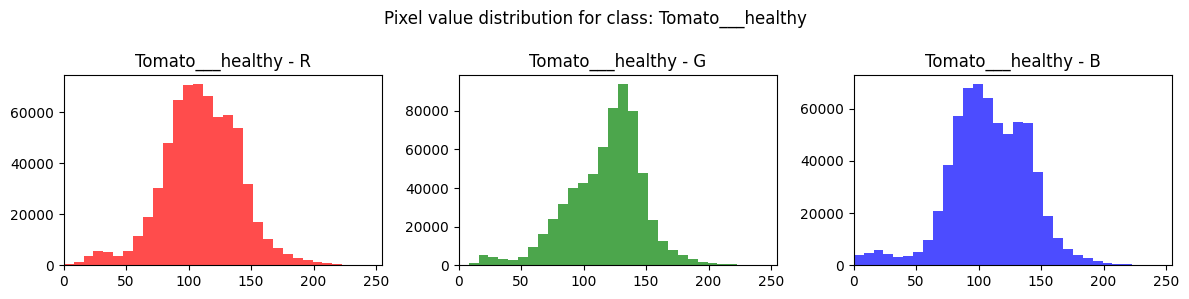

In [24]:
plot_pixel_distribution(Path(TRAIN_DIR), n_classes=12)

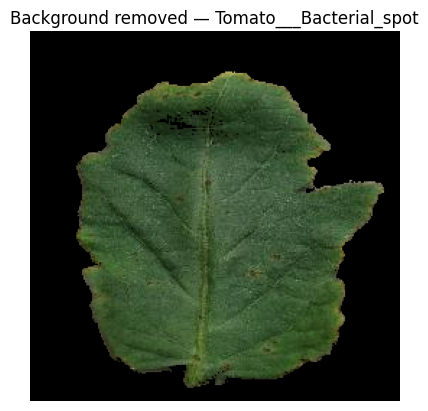

In [25]:
# Pick the first image from the first class as a demo
demo_class = [d for d in sorted(Path(TRAIN_DIR).iterdir()) if d.is_dir()][0]
demo_img = list(demo_class.glob('*'))[0]

im = remove_background(str(demo_img))
plt.imshow(im)
plt.axis('off')
plt.title(f'Background removed — {demo_class.name}')
plt.show()


In [27]:
# Build list of all image paths and labels
image_paths, labels = [], []
class_dirs = sorted([d for d in Path(TRAIN_DIR).iterdir() if d.is_dir()])
class_to_idx = {d.name: i for i, d in enumerate(class_dirs)}

for d in class_dirs:
    for p in d.glob('*'):
        image_paths.append(str(p))
        labels.append(class_to_idx[d.name])

train_dataset = TomatoDataset(image_paths, labels, transform=train_transform)
print(f'Dataset size: {len(train_dataset)} images, {len(class_to_idx)} classes')


Dataset size: 10000 images, 10 classes


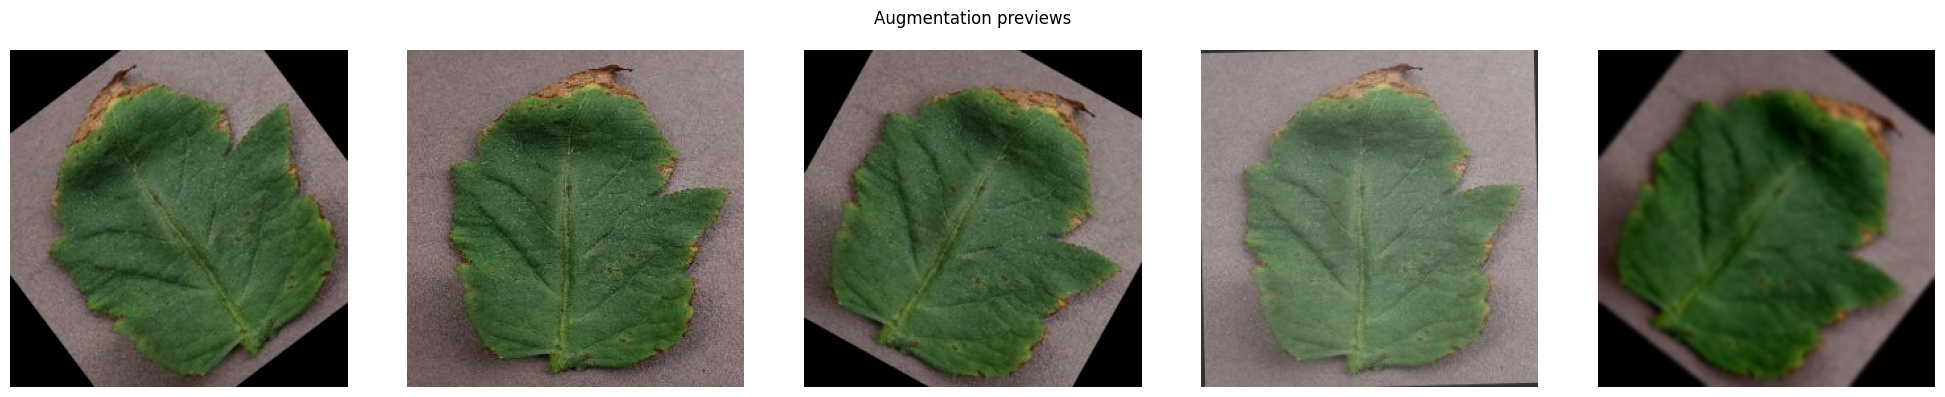

In [28]:
# Preview augmentations on a single image
sample_path = image_paths[0]
sample = cv2.imread(sample_path)
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax in axes:
    augmented = train_transform(image=sample)["image"]
    ax.imshow(augmented)
    ax.axis("off")
fig.suptitle("Augmentation previews")
plt.tight_layout()
plt.show()